In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import invwishart



# --------------------------------------------------------
# 0. Setting up the environment and importing necessary libraries
# --------------------------------------------------------
# This script implements the penalty function approach by Uhlig (2005) to identify structural shocks in a VAR model.
# The script is optimized for a local environment where the data is stored in an Excel file named 'uhligdata.xls'.
# You have to ensure that the 'uhligdata.xls' file is in the same directory as this script for it to run successfully.
# JAX is heavily used in the optimization part of the code, so make sure to have JAX installed in your Python environment.

# ==========================================
# 1. DATA PREPARATION FOR THE LOCAL ENVIRONMENT
# ==========================================
# Importing data from the local file 'uhligdata.xls' located in the same directory as this script.
# NOTE: Make sure to have the 'uhligdata.xls' file in the same directory as this script for it to run successfully.
# We save the data in a DataFrame and drop any rows with missing values to ensure clean data for analysis.
filepath = 'uhligdata.xls'
df = pd.read_excel(filepath).dropna()


# In this code block, we select the variables that must be transformed using the logarithm. 
# We apply the natural logarithm to these variables and multiply by 100 to convert them into percentage terms. 
# This transformation is suggested by Uhlig (2005: p. 392) where he clarifies that he did NOT take the logarithm of the federal funds rate (FEDFUNDS). 
# The reason is technical: the federal funds rate can take values close to zero, which would lead to issues with the logarithm.
cols_to_log = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'BOGNONBR', 'TOTRESNS']
for col in cols_to_log:
    df[col] = np.log(df[col]) * 100


# These two lines of code prepare the data for the VAR model. We define the order of the columns 
# we want to use and extract their values into a NumPy array called Y_raw.
ordered_cols = ['GDPC1', 'GDPDEF', 'CPRINDEX', 'FEDFUNDS', 'BOGNONBR', 'TOTRESNS']
Y_raw = df[ordered_cols].values


# The next code block constructs the lagged variables for the VAR model. We set the number of lags (p) to 12, which is a common choice for monthly data.
# First, we calculate the number of observations (T) after accounting for the lags. We then create a new matrix X that will hold the lagged values of the variables.
# T_raw is the total number of observations in Y_raw, and we subtract p to get the number of usable observations for the VAR model. 
# The line Y = Y_raw[p:] creates the dependent variable matrix Y, which contains the values of the variables starting from the (p+1)-th observation, 
# so we have of course lost the first p observations due to the lag structure. The next line, X = np.zeros((T, m * p)), 
# initializes the matrix X with zeros, where T is the number of observations and m is the number of variables. The for loop fills the matrix X with the lagged values of Y_raw.
# Note that in Python, we have to have a huge matrix with all the lagged explanatory variables. 
# The left side, X[:, i*m : (i+1)*m], describes where to allocate the lagged values. The : means that in each round in the for loop, 
# we fill all rows of X for the columns corresponding to the i-th lag of all variables. As p = 12, i ranges from 0 to 11. The part i*m : (i+1)*m 
# defines the column indices for the i-th lag of all m variables. For instance, when i = 0, we fill the columns from 0 to m-1 with the first lag of all variables, 
# when i = 1, we fill the columns from m to 2*m-1 with the second lag, and so on.
# The right side, Y_raw[p - i - 1 : T_raw - i - 1], selects the appropriate lagged values from Y_raw. For the first six columns of X (i = 0), 
# we take the values from Y_raw starting from the p-th observation up to T_raw - 1, so we drop the upper 11 rows and the last row from Y_raw. 
# For the next six columns (i = 1), we drop the upper 10 rows and the last two rows from Y_raw, and so on. This way, we fill the matrix X with the lagged values of the variables,
# ensuring that the rows of X and Y are aligned correctly for the VAR model estimation.
p = 12
T_raw, m = Y_raw.shape
T = T_raw - p # This is the line where we lose the first p observations due to the lag structure
Y = Y_raw[p:] # This creates the dependent variable matrix Y, which contains the values of the variables starting from the (p+1)-th observation. In plain English, we have lost the first 12 observations due to the lag structure.
X = np.zeros((T, m * p)) # This initializes the matrix X with zeros, where T is the number of observations and m is the number of variables.
for i in range(p):
    X[:, i*m : (i+1)*m] = Y_raw[p - i - 1 : T_raw - i - 1] # In the first six columns of X (i = 0), we take the values from Y_raw starting from the p-th observation 
    # up to T_raw - 1, so we drop the upper 11 rows and the last row from Y_raw. For the next six columns (i = 1), we drop the upper 10 rows and the last two rows from Y_raw, and so on. 
    # This way, we fill the matrix X with the lagged values of the variables, ensuring that the rows of X and Y are aligned correctly for the VAR model estimation.

# This last line in the block adds a column of ones to the matrix X to account for the intercept in the VAR model. Now, X is ready for use. 
X = np.hstack([X, np.ones((T, 1))])

In [17]:
import jax
import jax.numpy as jnp
from scipy.optimize import minimize

# ==========================================
# STANDARD DEVIATIONS FOR NORMALIZATION
# ==========================================
# As Uhlig (2005, pp. 413-414) explains, to calculate the penalty function, we need to normalize the impulse responses 
# by the standard deviation of the first difference of the variables.
# This step ensures that the movements in interest rates and prices are on the same scale ("comparing apples to apples") when they are included in the penalty sum.
# This is done in the next line of code, where we compute the standard deviation of the first difference of Y_raw along the time axis (axis=0).
sigma = np.std(np.diff(Y_raw, axis=0), axis=0)

# ==========================================
# 2. PENALTY FUNCTION (JAX IMPLEMENTATION)
# ==========================================
# We JIT-compile this function (Just-In-Time) for lightning-fast execution.
# As a first step, we will define the penalty function that takes the impulse vector a, 
# the pre-computed orthogonal Cholesky impulse responses for the K=6 horizon (irf_base_K),
# and the standard deviation vector for normalization (sigma_jax). The function will compute the penalty 
# objective that we want to minimize. The optimizer will modify alpha to find the optimal solution that minimizes the penalty function.
@jax.jit
def penalty_objective(alpha, irf_base_K, sigma_jax):
    """
    ARGUMENTS:
    alpha: The m-dimensional unit vector that the optimizer modifies. This alpha and the Cholesky decomposition of the residual covariance matrix (contained in irf_base_K) together determine the candidate impulse response for the K=6 horizon.  
    irf_base_K: The pre-computed, orthogonal Cholesky impulse responses 
                for the K=6 horizon (shape: 6 x m x m).
    sigma_jax: The "JAX-ed version" of the standard deviation vector for normalization.
    """
    # 1. Normalize the vector alpha to the unit sphere (unit length). This is crucial for the optimization process, 
    # as it ensures that we are only changing the direction of the vector, not its magnitude. By placing normalization INSIDE the objective function, 
    # we guarantee that the optimizer will always work with unit vectors, which is essential for the correct functioning of the penalty method.
    # As we draw alpha randomly, this architecture ensures that we will have vectors of unit lenths, before calculating the penalty. In the paper,
    # Uhlig (2005, p. 415) uses polar coordinates to ensure that the optimization is performed on the unit sphere. 
    # In our implementation, we achieve the same result by normalizing alpha inside the objective function.
    alpha_norm = alpha / jnp.linalg.norm(alpha)
    
    # 2. Compute the candidate impulse response for the K=6 horizon
    # jnp.dot multiplies a (6, m, m) matrix with a (m,) vector -> (6, m) matrix.
    # This part of the architecture accelerates execution by assigning candidate_irf the whole, six-month-long impulse response for the current candidate vector alpha_norm, 
    # which is then used to calculate the penalty terms for all six months in one go, as prescribed by Uhlig (2005, p. 415) with K = 5 (containing the first six months).
    # NOTE: This candidate_irf contains the impulse responses for all m variables across the six-month horizon, 
    # which allows us to efficiently compute the penalty terms for all restricted variables and all months in one step.
    # This is more than we need - we have sign restrictions only on four variables, but we will extract those specific variables in the next step.
    candidate_irf = jnp.dot(irf_base_K, alpha_norm)
    
    # 3. Extract the 4 restricted variables and normalize them by their standard deviations.
    # This is the part where we start implementing Uhlig's (2005, p. 413) penalty function. We extract the impulse responses for the four restricted variables 
    # (prices, raw materials, interest rates, and reserves) across the six-month horizon and normalize them by their respective standard deviations.
    # Indices based on the data frame:
    # 1: GDPDEF, 2: CPRINDEX, 3: FEDFUNDS, 4: BOGNONBR. Sign restrictions come from Uhlig (2005, pp. 387-388).
    x1 = candidate_irf[:, 1] / sigma_jax[1]  # Prices (measured with the GDP Deflator): should not increase (x <= 0 is the good sign)
    x2 = candidate_irf[:, 2] / sigma_jax[2]  # Prices of Raw Materials (measured with the Commodity Price Index): should not increase (x <= 0 is the good sign)
    
    # Reverse the sign of the interest rate impulse response (l_j = -1)
    x3 = -candidate_irf[:, 3] / sigma_jax[3] # Federal Funds Rate: should not decrease (x >= 0 is the good sign, reversed x <= 0)
    x4 = candidate_irf[:, 4] / sigma_jax[4]  # Non-borrowed Reserves: should not increase (x <= 0 is the good sign)
    
    # 4. Concatenate all penalty terms into a single long vector
    # In this step, we combine the penalty terms for all four restricted variables across the six-month horizon into a single vector x. 
    # This allows us to apply Uhlig's asymmetric penalty function to all terms in one go, which is computationally efficient and straightforward to implement.
    # The result is a 24-dimensional vector (4 variables x 6 months) that contains all the normalized impulse responses for the restricted variables, 
    # ready for the penalty calculation.
    x = jnp.concatenate([x1, x2, x3, x4])
    
    # 5. Uhlig's (2005, p. 413) asymmetric penalty function:
    # If x <= 0, then f(x) = x (small reward for the correct direction)
    # If x > 0, then f(x) = 100 * x (severe penalty for the wrong direction)
    # The next line applies this piecewise function to all elements of the vector x. The jnp.where function is used to efficiently apply the condition across the entire vector,
    # resulting in a new vector of penalties that will be summed up in the next step to get the objective function value. 
    # This architecture allows us to implement Uhlig's asymmetric penalty function in a vectorized manner, which is both elegant and computationally efficient.
    # The resulting vector 'penalties' contains the penalty values for all 24 terms (4 variables x 6 months), which will be summed to get the total penalty that the optimizer will minimize.
    penalties = jnp.where(x <= 0, x, 100.0 * x)
    
    # 6. Objective function to minimize (the double sum of penalties)
    # This line sums up all the penalty terms to get the total penalty that we want to minimize. The optimizer will adjust alpha 
    # to find the direction that minimizes this total penalty,
    # which corresponds to the structural shock that best satisfies the sign restrictions. By summing all the penalties, 
    # we ensure that the optimizer takes into account the entire horizon and all restricted variables when searching for the optimal solution.
    # In the minimization process, the optimizer will try to find the vector alpha that minimizes this total penalty, 
    # which corresponds to the structural shock that best satisfies the sign restrictions across all restricted variables and the six-month horizon.
    return jnp.sum(penalties)

# Finally, we create the function that returns both the objective function value and the exact gradient. This is JAX's real magic!
# JAX uses Reverse-Mode Automatic Differentiation to compute the gradient of the penalty objective with respect to vector alpha.
loss_and_grad = jax.jit(jax.value_and_grad(penalty_objective))

In [18]:
# ==========================================
# 3. REDUCED-FORM VAR AND NUMERICALLY STABILIZED POSTERIOR
# ==========================================
# In Section 3 of the script, we estimate the reduced-form VAR and compute the posterior distribution of the parameters.
# The first three lines compute the OLS estimator for the VAR coefficients (B_hat) and the residuals (U). 
# NOTE: In a Bayesian VAR framework, we are entitled to use a simple OLS estimator for the VAR coefficients because we are assuming homoskedastic errors and a flat prior, 
# which simplifies the posterior distribution.
# We then calculate the scale matrix (S_scale) for the inverse Wishart distribution, which is used to draw the covariance matrix of the errors in the Monte Carlo simulation.
# \hat{B} = (X^T X)^{-1} X^T Y is the OLS estimator for the VAR coefficients, where X is the matrix of lagged variables and Y is the matrix of dependent variables.
XX = X.T @ X
XX_inv = np.linalg.inv(XX)
XX_inv = (XX_inv + XX_inv.T) / 2.0  # Perfect symmetry for the Wishart distribution

# As we assume homoskedastic errors, the posterior mean of the regression coefficients is the OLS estimator, which is computed as B_hat = (X^T X)^{-1} X^T Y.
# The second line computes the residuals (U) from the OLS estimation, which are used to calculate the scale matrix for the inverse Wishart distribution.
B_hat = XX_inv @ X.T @ Y
U = Y - X @ B_hat

# This is the scale matrix for the inverse Wishart distribution, which is used to draw the covariance matrix of the errors in the Monte Carlo simulation.
# The scale matrix is the first parameter in the inverse Wishart distribution, and it is computed as U^T U, where U are the residuals from the OLS estimation.
S_scale = U.T @ U
# To ensure perfect symmetry for the Wishart distribution, we average S_scale with its transpose. This step is crucial because the Wishart distribution requires 
# a strictly symmetric positive definite scale matrix, and due to numerical issues, S_scale might not be perfectly symmetric.
S_scale = (S_scale + S_scale.T) / 2.0 

In [19]:
# --------------------------------------------------------
# 4. PENALTY FUNCTION OPTIMIZATION (JAX + SciPy BFGS)
# --------------------------------------------------------
import time
from scipy.optimize import minimize

# These two hyperparameters control the optimization process: n_keep is the number of successful optimizations we want to collect, 
# and n_steps is the horizon for the impulse responses.
n_keep = 1000
n_steps = 60

# The next two lists will store the valid impulse response functions (IRFs) and forecast error variance decompositions (FEVDs) that we collect during the optimization process.
valid_irfs_penalty = []
valid_fevds_penalty = []

# When starting the optimization process, we print a message to indicate that the penalty function optimization is beginning, 
# and we record the start time to measure how long the process takes.
print("Starting penalty function optimization (JAX + SciPy BFGS)...")
start_time = time.time()

# -----------------------------------------------------------------------------
# 4.1. Cholesky decomposition of XX_inv with jitter for numerical stability
# -----------------------------------------------------------------------------
# This section is NOT part of the loop because we only need to compute the Cholesky decomposition of XX_inv once, 
# and we can reuse it for all draws in the Monte Carlo simulation.
# The jitter for the Cholesky decomposition is added to handle cases where the matrix XX_inv might be close to singular, 
# which can happen in small samples or with highly correlated regressors.
# This code block attempts to compute the Cholesky decomposition of the inverse of X^T X (XX_inv). If XX_inv is impossible to decompose due to numerical issues 
# (e.g., it is not positive definite), it adds a small jitter (1e-9 times the identity matrix) to ensure that the matrix is 
# positive definite and the Cholesky decomposition can be computed successfully.
# This manipulation is necessary because the Cholesky decomposition requires the input matrix to be positive definite, 
# and in some cases, due to numerical issues, XX_inv might not be perfectly so. By adding a small jitter, we ensure that the decomposition 
# can be performed without errors, allowing us to proceed with the Monte Carlo simulation. This manipulation does NOT distort the results in any meaningful way, 
# as the jitter is extremely small and only serves to ensure numerical stability.
# When we will soon perform the draws for the VAR coefficients, we will need to use the Cholesky factor of XX_inv to 
# transform the standard normal draws into draws that reflect the posterior distribution of the coefficients.
try:
    chol_XX_inv = np.linalg.cholesky(XX_inv)
except np.linalg.LinAlgError:
    chol_XX_inv = np.linalg.cholesky(XX_inv + np.eye(XX_inv.shape[0]) * 1e-9)

draw_count = 0
successful_opts = 0

# Here we start the SciPy grinder, which will run until we have collected n_keep successful optimizations. 
while successful_opts < n_keep:
    draw_count += 1
    
    #-------------------------------------
    # 1. Posterior draws (B, Sigma)
    #-------------------------------------
    # This is where we draw from the posterior distribution of the covariance matrix of the errors (Omega) using the inverse Wishart distribution.
    Omega_draw = invwishart.rvs(df=T, scale=S_scale)

    # The next small block attempts to compute the Cholesky decomposition of the drawn covariance matrix (Omega_draw). 
    # Similar to the previous block, if Omega_draw is not positive definite, we add a small jitter to ensure that the decomposition can be performed successfully.
    # NOTE: Omega_draw is the covariance matrix of the errors for any t, supposed to be constant over the periods, 
    # and we need its Cholesky factor to transform the standard normal draws into draws that reflect the posterior distribution of the errors.
    try:
        chol_Omega = np.linalg.cholesky(Omega_draw)
    except np.linalg.LinAlgError:
        chol_Omega = np.linalg.cholesky(Omega_draw + np.eye(m) * 1e-9)
    
    # This is where we draw from the posterior distribution of the VAR coefficients (B). 
    # Under the hood, we draw a standard normal matrix Z_B of the same shape as B_hat, and then we transform it using the Cholesky 
    # factors of XX_inv and Omega_draw to get a draw from the posterior distribution of B.
    # In the line B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Omega.T, we start with the posterior mean (B_hat) and add a 
    # random draw that reflects the uncertainty around this mean, depending on the variability in the data (captured by Omega_draw) 
    # and the precision of the estimates (captured by XX_inv).
    Z_B = np.random.randn(X.shape[1], m)
    B_draw = B_hat + chol_XX_inv @ Z_B @ chol_Omega.T
    
    # -----------------------------------------------------
    # 2. Companion form és the raw impulse responses
    # -----------------------------------------------------
    # In this code block, we construct the companion form of the VAR model using the drawn coefficients (B_draw) 
    # and compute the impulse response functions (IRFs) for each draw. Note that the coefficient matrix B_draw includes the coefficient for p = 12 lags. 
    # Calculating the IRFs in this structure would be a nightmare, so we simplify the system into a gigantic VAR(1) system, which is called the companion form.
    # This companion form is matrix Gamma, which is a block matrix that contains the coefficients of the VAR model in a way that allows us to compute the IRFs easily.
    B_ar = B_draw[:-1, :]
    Gamma = np.zeros((m * p, m * p))
    Gamma[:m, :] = B_ar.T
    Gamma[m:, :-m] = np.eye(m * (p - 1))
    
    # This is the selection matrix J, which is used to extract the relevant parts of the IRFs from the companion form.
    J = np.zeros((m, m * p))
    J[:m, :m] = np.eye(m)
    
    # This block computes the IRFs for n_steps periods using the companion form. We initialize a base IRF matrix (irf_base) 
    # and a carry matrix that starts as the identity matrix. The role of the carry matrix is to keep track of the 
    # cumulative effect of the shocks as we iterate through the periods.
    # Note that in the code below, chol_Omega is the Cholesky factor of the drawn covariance matrix of the errors. An irf_base is computed for each period k, 
    # which captures the response of the system to a shock in the first period, and then we update the carry matrix by multiplying it with the companion matrix 
    # Gamma to get the cumulative effect for the next period. This way, we can compute the IRFs for all n_steps periods efficiently.
    # We have to apply J twice in the computation of irf_base to extract the relevant parts of the IRFs from the companion form, and we multiply by chol_Omega to 
    # incorporate the scale of the shocks as determined by the drawn covariance matrix.
    irf_base = np.zeros((n_steps, m, m))
    carry = np.eye(m * p)
    for k in range(n_steps):
        irf_base[k] = J @ carry @ J.T @ chol_Omega
        carry = carry @ Gamma
        
    # The penalty function only requires the first 6 months of the IRFs (K=6), so we extract that part of the irf_base to create irf_base_K, 
    # which will be used in the optimization process: it is to be multiplied by the impulse vector a to get the candidate IRF for the penalty calculation.
    irf_base_K = jnp.array(irf_base[:6, :, :])
    
    # ------------------------------------------------------
    # 3. Optimization with SciPy BFGS algorithm and JAX gradients
    # ------------------------------------------------------
    # These two lines set up the optimization process. We initialize variables to keep track of the best penalty value and the corresponding alpha.
    # NOTE: Uhlig (2005) labels the vector a as the "impulse vector" which comes from the Cholesky decomposition of the covariance matrix of the errors, and a vector alpha
    # that is of unit length. We are looking for the minimizing vector a by systematically adjusting the vector alpha of unit length.
    best_penalty = np.inf
    best_alpha = None
    
    # Two attempts with different starting points to avoid local minima. The optimization process can be sensitive to the initial guess for alpha, 
    # so we run the optimization twice with different random starting points to increase the chances of finding a good solution that satisfies the sign restrictions.
    # In the first step, we generate a random alpha_init of dimension m, which is then normalized to have unit length. 
    # This serves as the initial guess for the optimization process.
    for _ in range(2):
        alpha_init = np.random.randn(m)
        alpha_init = alpha_init / np.linalg.norm(alpha_init)
        
        # The 'jac = True' argument tells SciPy that the loss_and_grad function returns both the objective function value and the gradient, 
        # which allows the BFGS algorithm to use the gradient information for more efficient optimization.
        # This part of the code calls the minimize function from SciPy to perform the core optimization task. 
        # As arguments, we pass the loss_and_grad function, the initial vector alpha_init,
        # the arguments for the penalty function (irf_base_K and sigma), and specify that we want to use the BFGS algorithm with the provided gradient. 
        # The optimization will try to find the vector alpha that minimizes the penalty function,
        # which corresponds to the structural shock that best satisfies the sign restrictions across all restricted variables and the six-month horizon.
        # The output "res" is an object that contains information about the optimization result, including whether it was successful and the value of the objective 
        # function at the optimal solution.
        res = minimize(loss_and_grad, alpha_init, args=(irf_base_K, sigma), 
                       method='BFGS', jac = True, options = {'maxiter': 100})
        
        # After the optimization, we check if it was successful and store the best penalty value and the corresponding vector alpha.
        # The part res.success checks if the optimization algorithm converged successfully, and res.fun gives us the value of the penalty function at the optimal solution.
        # The part res.x gives us the optimal vector alpha that minimizes the penalty function.
        if res.success and res.fun < best_penalty:
            best_penalty = res.fun
            best_alpha = res.x
            
    # -------------------------------------------------------------------
    # 4. Finalizing the IRF and FEVD for the full 60-month horizon
    # -------------------------------------------------------------------
    # If the optimization was successful and a valid minimum was found, we proceed to compute 
    # the actual macroeconomic responses using the optimal impulse vector.
    if best_alpha is not None:
        
        # This line seems to be reduntant: In the penalty_objective function, we already normalize the vector alpha to have unit length before calculating the penalty.
        # But NOTE: The BFGS optimizer does not necessarily return a unit vector as the optimal solution. On the one hand, the penalty_objective function 
        # ensures that the optimization process is performed on the unit sphere by normalizing the vector alpha inside the objective function, but, on the other hand, 
        # the final output of the optimization (best_alpha) might not be a unit vector because the optimizer is not constrained to return unit vectors.
        # Formally speaking, the penalty_objective function does NOT constrain the optimization to the unit sphere, it only normalizes the vector alpha when calculating the penalty.
        # Our penalty_objective function is totally invariant with respect to the magnitude of alpha, as it normalizes alpha to alpha_norm before calculating the penalty. 
        # This means that any scalar multiple of alpha will yield the same penalty value, but the optimizer might not return a unit vector as the optimal solution. 
        best_alpha = best_alpha / np.linalg.norm(best_alpha)
        
        # The optimal_irf is computed by multiplying the full horizon irf_base (which contains the IRFs for all n_steps periods) with the optimal vector best_alpha.
        # The notation we apply here is wholly consistent with script for the sign restriction approach as the Cholesky decomposition of the residual covariance matrix is 
        # in the irf_base, and the optimal vector best_alpha is the one that minimizes the penalty function based on the first six months of the IRFs.
        optimal_irf = irf_base @ best_alpha
        
        # Variance decomposition (FEVD) for the optimal IRF. We calculate the cumulative sum of squared impulse responses 
        # or the identified shock (var_identified) and the total variance (var_total), 
        # and then we compute the FEVD as the percentage of variance explained by the identified shock. 
        # This gives us insight into how much of the forecast error variance of each variable can be attributed to the identified shock over the horizon.
        var_identified = np.cumsum(optimal_irf**2, axis=0)
        var_total = np.cumsum(np.sum(irf_base**2, axis=2), axis=0)
        fevd = (var_identified / var_total) * 100
        
        valid_irfs_penalty.append(optimal_irf)
        valid_fevds_penalty.append(fevd)
        successful_opts += 1
        
        if successful_opts % 100 == 0:
            print(f"Collected: {successful_opts} / {n_keep} (elapsed time: {time.time() - start_time:.2f} seconds)")

print(f"\nSuccessful runs! {successful_opts} optimized paths yielded from {draw_count} posterior draws.")
print(f"Total run time: {time.time() - start_time:.2f} seconds.")

Starting penalty function optimization (JAX + SciPy BFGS)...
Collected: 100 / 1000 (elapsed time: 18.09 seconds)
Collected: 200 / 1000 (elapsed time: 43.97 seconds)
Collected: 300 / 1000 (elapsed time: 65.11 seconds)
Collected: 400 / 1000 (elapsed time: 90.03 seconds)
Collected: 500 / 1000 (elapsed time: 108.87 seconds)
Collected: 600 / 1000 (elapsed time: 125.60 seconds)
Collected: 700 / 1000 (elapsed time: 145.65 seconds)
Collected: 800 / 1000 (elapsed time: 165.58 seconds)
Collected: 900 / 1000 (elapsed time: 190.78 seconds)
Collected: 1000 / 1000 (elapsed time: 219.23 seconds)

Successful runs! 1000 optimized paths yielded from 5732 posterior draws.
Total run time: 219.23 seconds.


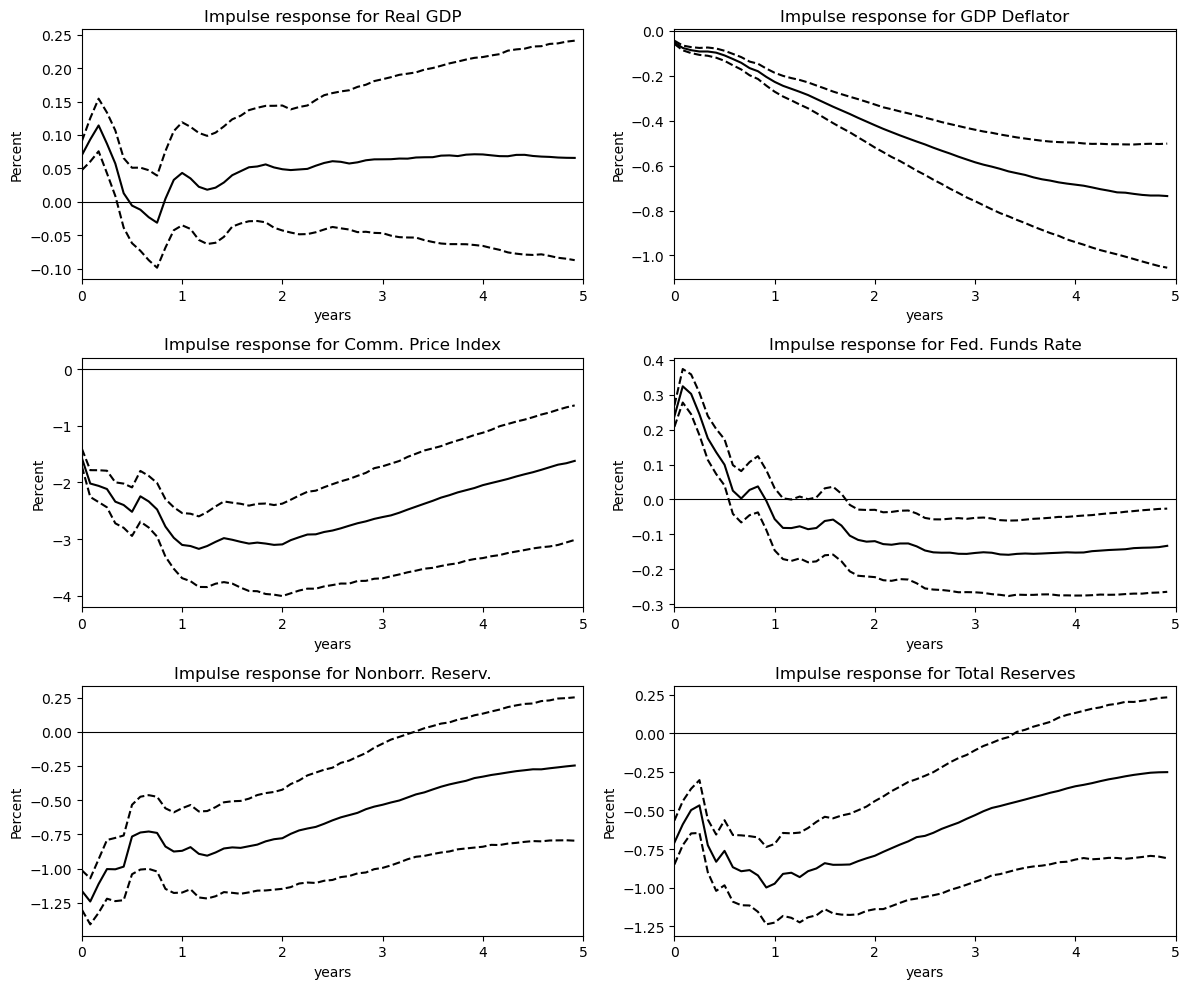

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 5. DRAWING UHLIG'S FIG. 14 - PENALTY FUNCTION IRFS
# ==========================================
# As a starting point, we convert the list of valid IRFs into a NumPy array for easier slicing and manipulation.
valid_irfs_penalty_arr = np.array(valid_irfs_penalty)

# We calculate the 16th, 50th (median), and 84th percentiles of the valid IRFs across 
# the Monte Carlo draws to construct the confidence intervals for the impulse responses.
irf_16 = np.percentile(valid_irfs_penalty_arr, 16, axis=0)
irf_50 = np.percentile(valid_irfs_penalty_arr, 50, axis=0)
irf_84 = np.percentile(valid_irfs_penalty_arr, 84, axis=0)

# Names of the variables in the right order for the plots. This will be used to label the subplots correctly, 
# matching the order of the variables in the data frame and the VAR model.
var_names = ['Real GDP', 'GDP Deflator', 'Comm. Price Index', 
             'Fed. Funds Rate', 'Nonborr. Reserv.', 'Total Reserves']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

# Horizon: 60 months. We create an array of integers from 0 to n_steps-1 to represent the time horizon for the impulse responses.
x = np.arange(n_steps)

for i in range(6):
    axes[i].plot(x, irf_50[:, i], 'k-', label='Median')
    axes[i].plot(x, irf_16[:, i], 'k--')
    axes[i].plot(x, irf_84[:, i], 'k--')
    axes[i].axhline(0, color='k', linewidth=0.8)
    axes[i].set_title(f"Impulse response for {var_names[i]}")
    
    # Formatting the x-axis to show years instead of months. We set the limits of the x-axis to be from 0 to n_steps, 
    # and we set the ticks at every 12 months (1 year) with corresponding labels in years.
    axes[i].set_xlim([0, n_steps])
    axes[i].set_xticks([0, 12, 24, 36, 48, 60])
    axes[i].set_xticklabels([0, 1, 2, 3, 4, 5])
    axes[i].set_xlabel('years')
    axes[i].set_ylabel('Percent')

plt.tight_layout()
# Saving the figure with a high resolution of 300 dpi to ensure that it looks good when printed or included in presentations. 
# The file is saved as 'Uhlig_Fig14_Penalty.jpg' in the current working directory.
plt.savefig('Uhlig_Fig14_Penalty.jpg', dpi=300)
plt.show()